In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Configuration esthétique
sns.set_theme(style="whitegrid")
np.random.seed(42) # Pour la reproductibilité

Exercice 1.1 : Génération de données Créez un DataFrame df de 5000 lignes respectant les lois de probabilité décrites dans le sujet.

Rappel : Utilisez np.random.uniform, np.random.normal, np.random.exponential.

In [18]:
# Paramètres
N = 5000

# 1. Génération des vecteurs
# TODO: Générer cpu_usage (Uniforme 10-90)
cpu_usage = np.random.uniform(10, 90, N)

# TODO: Générer memory (0.5 * CPU + Bruit Gaussien)
noise_memory = np.random.normal(loc=0, scale=5, size=N)
memory = 0.5 * cpu_usage + noise_memory

# TODO: Générer response_time (2 * CPU + 50 + Bruit Exponentiel)
noise_response = np.random.exponential(scale=10, size=N)
response_time = 2 * cpu_usage + 50 + noise_response

# TODO: Générer error_rate (Probabiliste selon le CPU)
# Astuce: Créez d'abord un vecteur de probabilités, puis tirez 0 ou 1
error_rate = []
for cpu in cpu_usage:
    if cpu > 80:
        # TODO
        error_rate.append(np.random.binomial(1, 0.30))
    else:
        # TODO
        error_rate.append(np.random.binomial(1, 0.01))

# Création du DataFrame
df = pd.DataFrame({
    'CPU_Usage': cpu_usage,
    'Memory': memory,
    'Response_Time': response_time,
    'Error_Rate': error_rate
})

df.head()



,CPU_Usage,Memory,Response_Time,Error_Rate
0,39.963210,16.996733,132.564787,0
1,86.057145,31.077050,222.592522,1
2,68.559515,32.218654,216.157598,0
3,57.892679,33.513708,169.550276,0
4,22.481491,13.928895,100.807507,0


Exercice 1.2 : Injection de défauts et Nettoyage

    Introduisez des NaN et des outliers.

    Imputez les valeurs manquantes par la médiane.

    Filtrez les outliers via la méthode IQR sur Response_Time.

In [19]:
# --- INJECTION DE DÉFAUTS (Ne pas modifier cette partie) ---
# Injection de NaN dans Memory (5%)
mask_nan = np.random.choice([True, False], size=N, p=[0.05, 0.95])
df.loc[mask_nan, 'Memory'] = np.nan

# Injection d'outliers dans Response_Time (1%)
mask_outlier = np.random.choice([True, False], size=N, p=[0.01, 0.99])
df.loc[mask_outlier, 'Response_Time'] = 9999
# -----------------------------------------------------------

# 1. Analyse des manquants
print("Valeurs manquantes avant nettoyage :\n", df.isnull().sum())

# TODO: Imputation de la colonne Memory par la médiane
df['Memory'] = df['Memory'].fillna(df['Memory'].median())

# 2. Filtrage IQR pour Response_Time
Q1 = df['Response_Time'].quantile(0.25)
Q3 = df['Response_Time'].quantile(0.75)
IQR = Q3 - Q1

# TODO: Définir les bornes lower_bound et upper_bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# TODO: Filtrer le DataFrame pour ne garder que les valeurs dans les bornes
df_clean = df[(df['Response_Time'] >= lower_bound) & (df['Response_Time'] <= upper_bound)]

print(f"Taille après filtrage : {len(df_clean)} lignes (perte de {N - len(df_clean)} lignes)")

Valeurs manquantes avant nettoyage :
 CPU_Usage          0
Memory           230
Response_Time      0
Error_Rate         0
dtype: int64
Taille après filtrage : 4960 lignes (perte de 40 lignes)


Exercice 2 : Analyse Univariée et Multivariée Tracez les distributions et la heatmap de corrélation.

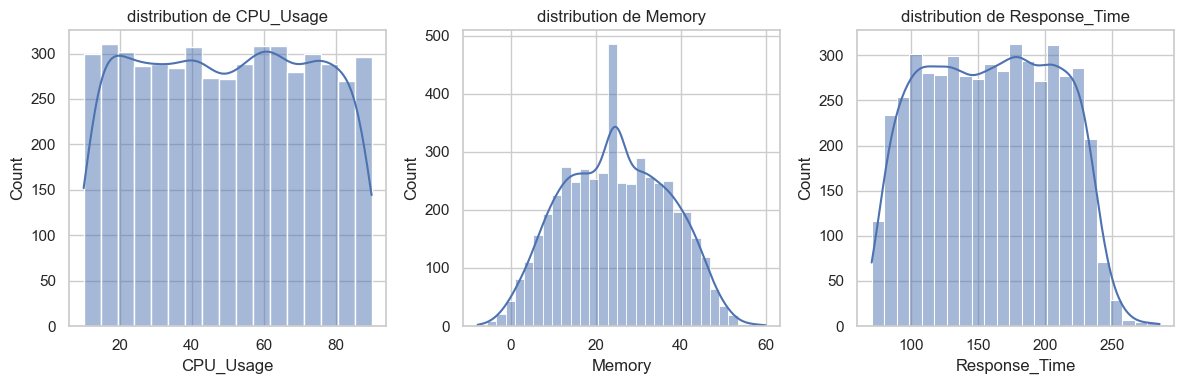

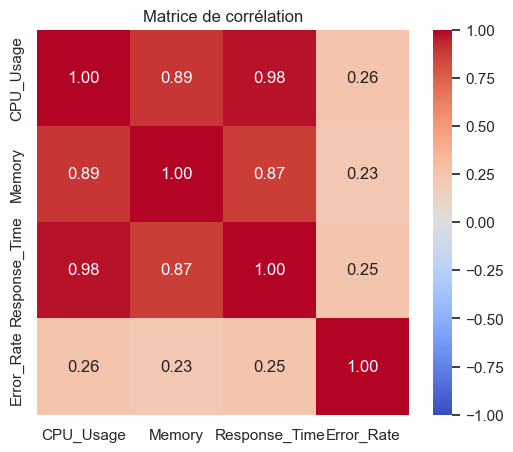

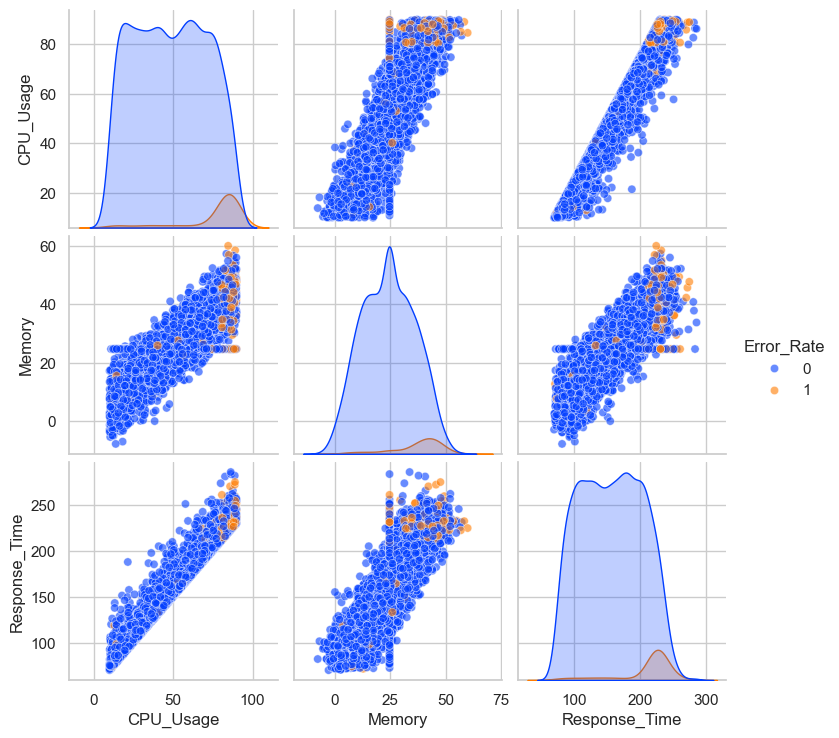

'\nSéparation nette selon le seuil du CPU, la probabilité d\'erreur augmente drastiquement passé un certain seuil de charge CPU.\n\nCorrélation forte, mais séparation indirecte pour les autres variables, Memory et Response_Time, on observe aussi que les erreurs sont situées vers les valeurs hautes.\n\nChevauchement des classes, la séparation n\'est pas "parfaite"\n'

In [20]:
# TODO: Histogrammes + KDE pour les variables quantitatives
plt.figure(figsize=(12, 4))

quants = ['CPU_Usage', 'Memory', 'Response_Time']
for i, col in enumerate(quants):
    plt.subplot(1, 3, i+1) # 1 ligne, 3 colonnes, index i+1
    sns.histplot(df_clean[col], kde=True)
    plt.title(f'distribution de {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

# TODO: Matrice de corrélation (heatmap)
plt.figure(figsize=(6, 5))

corr_matrix = df_clean.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matrice de corrélation')
plt.show()

"""
C'est une conséquence de notre méthode de génération. Nous avons défini memory = 0.5 * CPU + Bruit c'est donc une relation linéaire.
Il s'agit bien d'une causalité. Nous avons coder le fait que variation du CPU = variation de la mémoire.
"""

# TODO: Pairplot coloré par 'Error_Rate'
sns.pairplot(df_clean, hue='Error_Rate', vars=quants, palette='bright', plot_kws={'alpha': 0.6})
plt.show()

"""
Séparation nette selon le seuil du CPU, la probabilité d'erreur augmente drastiquement passé un certain seuil de charge CPU.

Corrélation forte, mais séparation indirecte pour les autres variables, Memory et Response_Time, on observe aussi que les erreurs sont situées vers les valeurs hautes.

Chevauchement des classes, la séparation n'est pas "parfaite"
"""

Exercice 3 : Régression Linéaire (Comparaison) Modélisez Response_Time = a * CPU_Usage + b. Comparez scikit-learn avec le calcul manuel : a=Var(X)Cov(X,Y)​

[Sklearn] a = 1.9958, b = 60.2997
[Manuel]  a = 1.9958, b = 60.2997


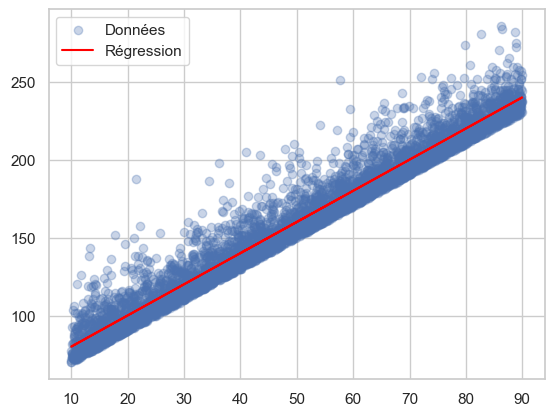

In [ ]:
X = df_clean['CPU_Usage']
Y = df_clean['Response_Time']

# --- MÉTHODE 1 : Scikit-Learn ---
# Reshape nécessaire pour sklearn (N, 1)
X_reshaped = X.values.reshape(-1, 1)

model = LinearRegression()
# TODO: Fit du modèle
model.fit(X_reshaped, Y)

a_sklearn = model.coef_[0]
b_sklearn = model.intercept_

print(f"[Sklearn] a = {a_sklearn:.4f}, b = {b_sklearn:.4f}")

# --- MÉTHODE 2 : Calcul Manuel ---
# Rappel: Covariance et Variance
# Attention à l'argument 'ddof' (Delta Degrees of Freedom) pour la cohérence
# Si on utilise n-1 (standard stats), ddof=1.

# TODO: Calculer covariance et variance
covariance = np.cov(X, Y, ddof=1)[0][1]
variance = np.var(X, ddof=1)

# TODO: Calculer a et b
a_manual = covariance / variance
b_manual = Y.mean() - a_manual * X.mean()

print(f"[Manuel]  a = {a_manual:.4f}, b = {b_manual:.4f}")

# --- Visualisation --
plt.scatter(X, Y, alpha=0.3, label='Données')
plt.plot(X, a_sklearn * X + b_sklearn, color='red', label='Régression')
plt.legend()
plt.show()